In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys, os, json, gzip, pprint, asyncio
import numpy as np
from datetime import datetime
from src.handlers.polymarket import PolymarketHandler

In [2]:
handler = PolymarketHandler()
df = pd.read_csv("src/data/historicalMarkets_1779089671.csv")
df = df.sort_values(by="liquidity", ascending=False, ignore_index=True)

In [3]:
z = handler.getPriceHistory_sync(
    "2287113", (
        "103350358078251759575620015806630569526173200134418067780745880701441873240597",
        "98603077546717676663420810575062588271330072816544253956294914089344114457911"
    ), interval = "max"
)
len(z["outcome_0"])

33

In [3]:
i = 1
market = pd.Series(df.iloc[i])
id = market["marketID"]
outcome0_id = market["outcome_0_ID"]
outcome1_id = market["outcome_1_ID"]

print("slug:", market["slug"])
print("marketID:", id)
print("outcome_0_ID:", outcome0_id)
print("outcome_1_ID:", outcome1_id)

results = json.loads(df.iloc[i].priceHistory.replace("'", '"'))

slug: will-the-new-orleans-saints-win-super-bowl-2026
marketID: 540228
outcome_0_ID: 73494436238665519387236622310812635825321910467243761467691818179752423769958
outcome_1_ID: 94668310614098355450367164052071835928899825768312927476956742571473300461200


Datapoint count: 33


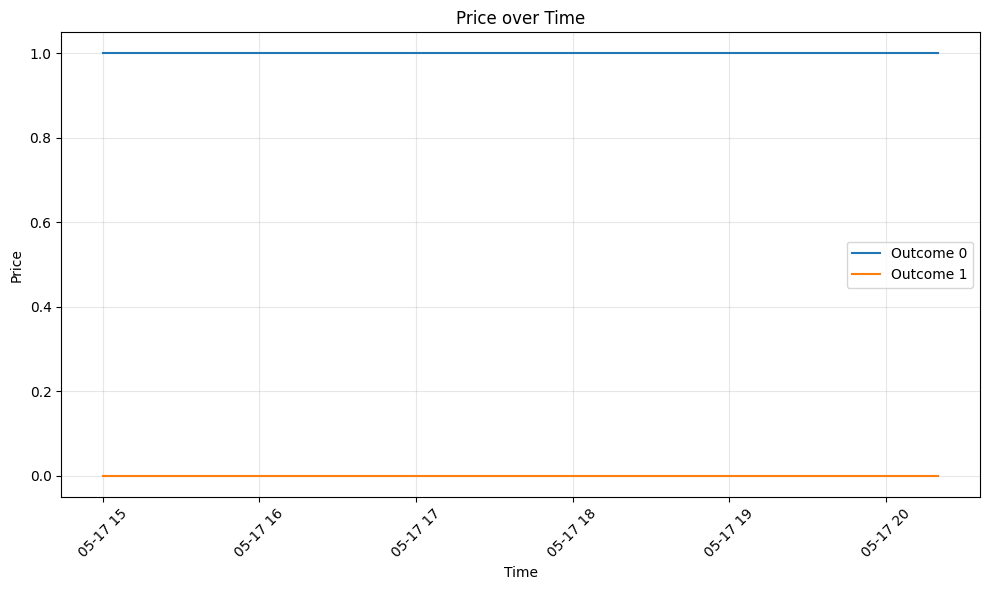

In [13]:
print("Datapoint count:", len(results["outcome_0"]))

# Outcome 0
prices_0 = [results["outcome_0"][i]["p"] for i in range(len(results["outcome_0"]))]
times_0 = [datetime.fromtimestamp(results["outcome_0"][i]["t"]) for i in range(len(results["outcome_0"]))]

# Outcome 1
prices_1 = [results["outcome_1"][i]["p"] for i in range(len(results["outcome_1"]))]
times_1 = [datetime.fromtimestamp(results["outcome_1"][i]["t"]) for i in range(len(results["outcome_1"]))]

plt.figure(figsize=(10, 6))
plt.plot(times_0, prices_0, label='Outcome 0')
plt.plot(times_1, prices_1, label='Outcome 1')

plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Price over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

{'active': True,
 'archived': False,
 'closed': True,
 'createdAt': '2025-04-30T10:43:16',
 'daysTillExpiry': -99,
 'description': 'This market will resolve to "Yes" if the New Orleans Saints '
                'win Super Bowl LX. Otherwise, this market will resolve to '
                '"No".  If at any point it becomes impossible for this team to '
                'win the Super Bowl based on the rules of the NFL (e.g. they '
                'are eliminated in the playoff bracket), this market will '
                'resolve immediately to "No".',
 'endDate': '2026-02-08T12:00:00',
 'events': ['super-bowl-champion-2026-731'],
 'eventsCount': 1,
 'hoursTillExpiry': -2364.9329484558334,
 'liquidity': '0',
 'liquidityNum': 0,
 'makerBaseFee': None,
 'marketID': '540228',
 'outcome_0_ID': '73494436238665519387236622310812635825321910467243761467691818179752423769958',
 'outcome_0_price': 0.0,
 'outcome_0_return': None,
 'outcome_1_ID': '9466831061409835545036716405207183592889982576831292

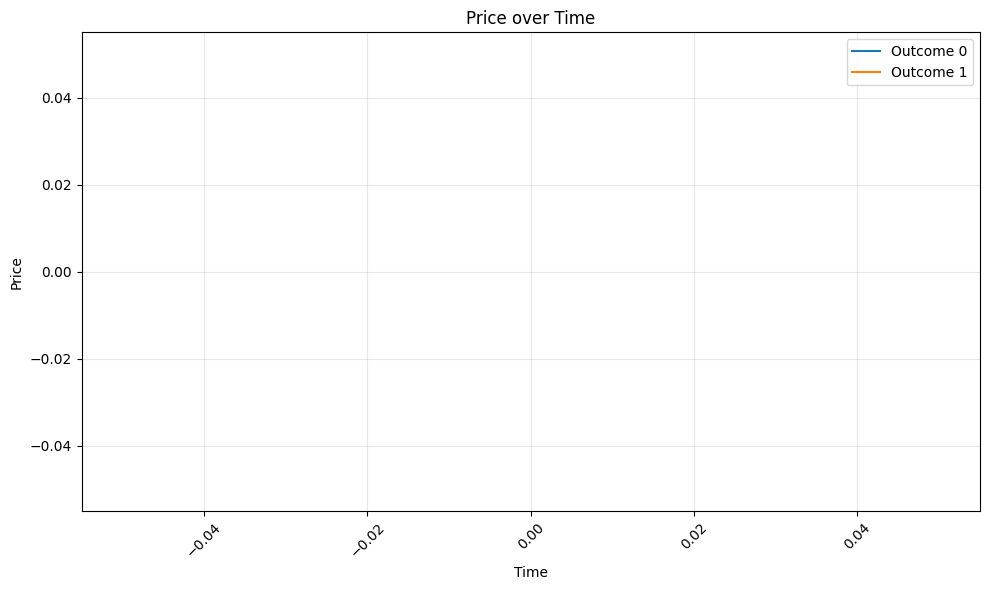

In [4]:
# Specific market data
z = handler.getMarket(slug="will-the-new-orleans-saints-win-super-bowl-2026", getPriceData = True)

pprint.pprint(z)

print("Datapoint count:", len(z["priceHistory"]["outcome_0"]))

# Outcome 0
prices_0 = [z["priceHistory"]["outcome_0"][i]["p"] for i in range(len(z["priceHistory"]["outcome_0"]))]
times_0 = [datetime.fromtimestamp(z["priceHistory"]["outcome_0"][i]["t"]) for i in range(len(z["priceHistory"]["outcome_0"]))]

# Outcome 1
prices_1 = [z["priceHistory"]["outcome_1"][i]["p"] for i in range(len(z["priceHistory"]["outcome_1"]))]
times_1 = [datetime.fromtimestamp(z["priceHistory"]["outcome_1"][i]["t"]) for i in range(len(z["priceHistory"]["outcome_1"]))]

plt.figure(figsize=(10, 6))
plt.plot(times_0, prices_0, label='Outcome 0')
plt.plot(times_1, prices_1, label='Outcome 1')

plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Price over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()